In [59]:
import csv
import pandas as pd

In [60]:
nodes = pd.read_csv(
    "/Users/yimengliu/Documents/Erdos_Institute/mgp/summer26-math-genealogy/data/processed/dataset_filled_subjects_new.csv"
)

In [61]:
nodes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 338532 entries, 0 to 338531
Data columns (total 12 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   id                             338532 non-null  int64  
 1   name                           338526 non-null  object 
 2   thesis                         307399 non-null  object 
 3   school                         276167 non-null  object 
 4   country                        322986 non-null  object 
 5   year                           277237 non-null  float64
 6   advisors                       338532 non-null  object 
 7   students                       338532 non-null  object 
 8   subject_code                   302106 non-null  float64
 9   subject_name                   302106 non-null  object 
 10  predicted_subject_code         133502 non-null  float64
 11  subject_prediction_confidence  136040 non-null  float64
dtypes: float64(4), int64(1), objec

In [64]:
year_count=[]
X=[]
for i in range(1,128):
    X.append(1899+i)
    year_count.append(len(nodes[nodes['year']==1899+i]))
#year_count

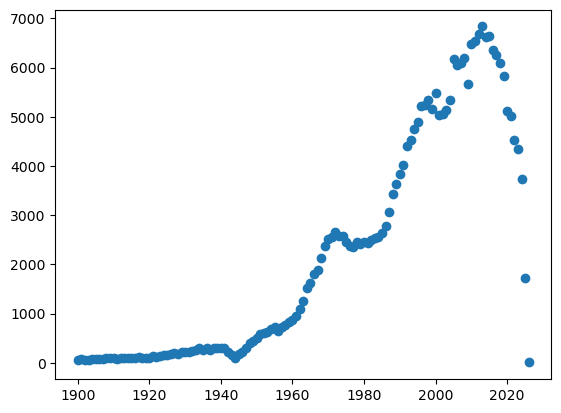

In [65]:
plt.scatter(X,year_count)

### Part I: Simple Expoential Smoothing

In [66]:
from statsmodels.tsa.api import SimpleExpSmoothing
simp_exp_smooth = SimpleExpSmoothing(year_count).fit(smoothing_level=0.5,
                                                                             optimized=False)

In [67]:
X_new=[]
for i in range(1,148):
    X_new.append(1899+i)
print(X_new)

[1900, 1901, 1902, 1903, 1904, 1905, 1906, 1907, 1908, 1909, 1910, 1911, 1912, 1913, 1914, 1915, 1916, 1917, 1918, 1919, 1920, 1921, 1922, 1923, 1924, 1925, 1926, 1927, 1928, 1929, 1930, 1931, 1932, 1933, 1934, 1935, 1936, 1937, 1938, 1939, 1940, 1941, 1942, 1943, 1944, 1945, 1946, 1947, 1948, 1949, 1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959, 1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026, 2027, 2028, 2029, 2030, 2031, 2032, 2033, 2034, 2035, 2036, 2037, 2038, 2039, 2040, 2041, 2042, 2043, 2044, 2045, 2046]


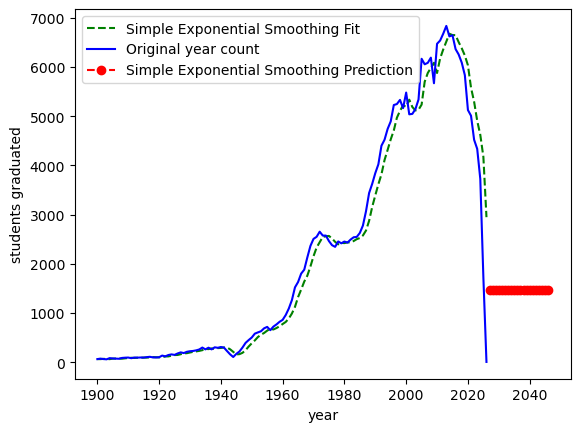

In [68]:
plt.plot(X_new[:-20],simp_exp_smooth.fittedvalues,'g--',label="Simple Exponential Smoothing Fit")
plt.plot(X_new[:-20],year_count,'b',label="Original year count")
plt.plot(X_new[-20:], 
         simp_exp_smooth.forecast(20),
         'r--o',
         label="Simple Exponential Smoothing Prediction")
plt.xlabel("year", fontsize=10)
plt.ylabel("students graduated", fontsize=10)
plt.legend()
plt.show()

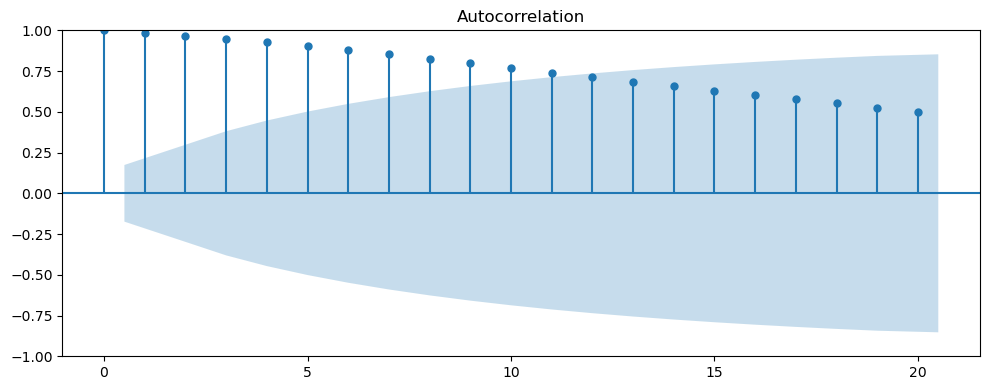

In [69]:
import matplotlib.pyplot as plt
import statsmodels.api as sm

fig, ax2 = plt.subplots(figsize=(10, 4))
sm.graphics.tsa.plot_acf(year_count, lags=20, ax=ax2)
plt.tight_layout()
plt.show()

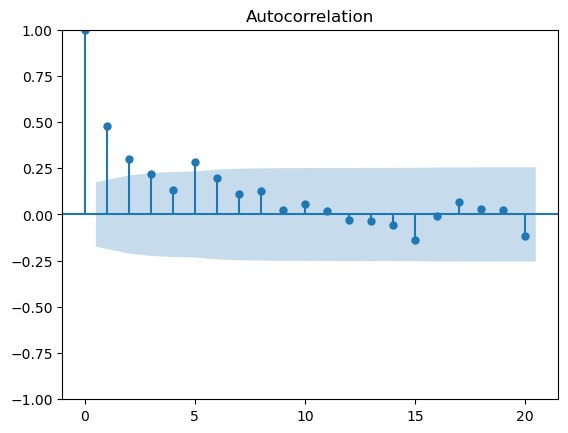

In [ ]:
#compute autocorrelation of slopes/derivatives
s = pd.Series(year_count).diff().dropna()
sm.graphics.tsa.plot_acf(s, lags=20)
plt.show()

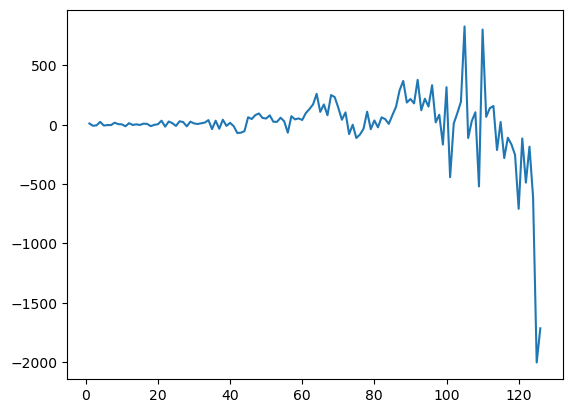

In [71]:
plt.plot(s)

We do the same analysis for `subject_name`=algebraic geometry, with `subject_code`=14

In [73]:
AG=nodes[nodes['subject_code']==14]

In [74]:
AG.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5916 entries, 824 to 338386
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   id                             5916 non-null   int64  
 1   name                           5916 non-null   object 
 2   thesis                         5583 non-null   object 
 3   school                         4998 non-null   object 
 4   country                        5800 non-null   object 
 5   year                           5034 non-null   float64
 6   advisors                       5916 non-null   object 
 7   students                       5916 non-null   object 
 8   subject_code                   5916 non-null   float64
 9   subject_name                   5916 non-null   object 
 10  predicted_subject_code         1717 non-null   float64
 11  subject_prediction_confidence  1717 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 

In [75]:
year_count_AG=[]
for i in range(1,128):
    year_count_AG.append(len(AG[AG['year']==1899+i]))

In [76]:
simp_exp_smooth_AG = SimpleExpSmoothing(year_count_AG).fit(smoothing_level=0.5,
                                                                             optimized=False)

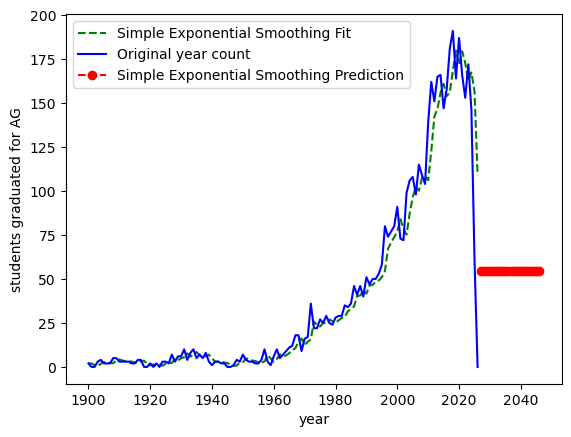

In [79]:
plt.plot(X_new[:-20],simp_exp_smooth_AG.fittedvalues,'g--',label="Simple Exponential Smoothing Fit")
plt.plot(X_new[:-20],year_count_AG,'b',label="Original year count")
plt.plot(X_new[-20:], 
         simp_exp_smooth_AG.forecast(20),
         'r--o',
         label="Simple Exponential Smoothing Prediction")
plt.xlabel("year", fontsize=10)
plt.ylabel("students graduated for AG", fontsize=10)
plt.legend()
plt.show()

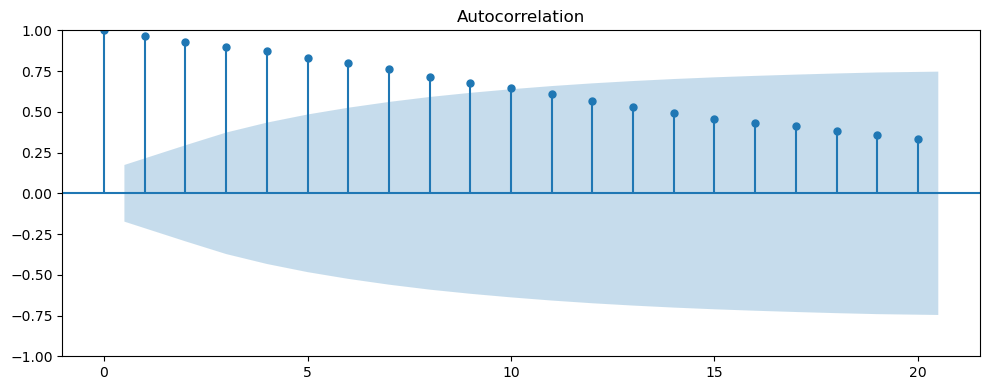

In [80]:
fig, ax2 = plt.subplots(figsize=(10, 4))
sm.graphics.tsa.plot_acf(year_count_AG, lags=20, ax=ax2)
plt.tight_layout()
plt.show()

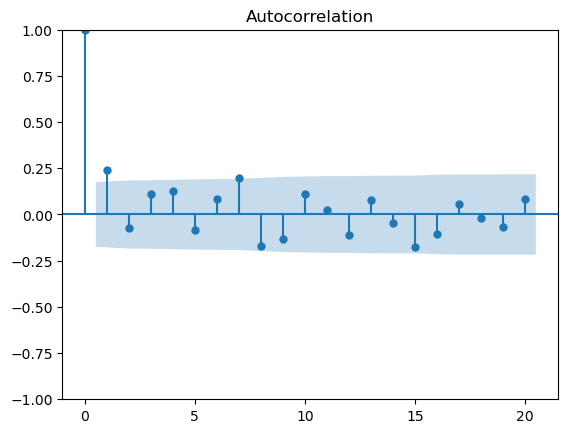

In [82]:
#compute autocorrelation of slopes
s = pd.Series(year_count_AG).diff().dropna()
sm.graphics.tsa.plot_acf(s, lags=20)
plt.show()

## Precentange

In [100]:
import numpy as np
codes=np.sort(nodes.subject_code.dropna().unique())
print(codes)

[ 0.  1.  3.  5.  6.  8. 11. 12. 13. 14. 15. 16. 17. 18. 19. 20. 22. 26.
 28. 30. 31. 32. 33. 34. 35. 37. 39. 40. 41. 42. 43. 44. 45. 46. 47. 49.
 51. 52. 53. 54. 55. 57. 58. 60. 62. 65. 68. 70. 74. 76. 78. 80. 81. 82.
 83. 85. 86. 90. 91. 92. 93. 94. 97.]


In [106]:
for i in range(0,63):
   print(codes[i])

0.0
1.0
3.0
5.0
6.0
8.0
11.0
12.0
13.0
14.0
15.0
16.0
17.0
18.0
19.0
20.0
22.0
26.0
28.0
30.0
31.0
32.0
33.0
34.0
35.0
37.0
39.0
40.0
41.0
42.0
43.0
44.0
45.0
46.0
47.0
49.0
51.0
52.0
53.0
54.0
55.0
57.0
58.0
60.0
62.0
65.0
68.0
70.0
74.0
76.0
78.0
80.0
81.0
82.0
83.0
85.0
86.0
90.0
91.0
92.0
93.0
94.0
97.0


In [113]:
M = np.zeros((63, 127))

for i in range(63):
    subject=codes[i]
    for j in range(127):
        M[i,j]=len(nodes[(nodes['subject_code']==subject)&(nodes['year']==1900+j)])/len(nodes[(nodes['subject_code'].notna())&(nodes['year']==1900+j)])

In [107]:
len(nodes[nodes['subject_code']==codes[15]])

6207

In [110]:
len(nodes[nodes['subject_code'].notna()])

302106

In [115]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

years = np.arange(1900, 2027)

valid = nodes[
    nodes["subject_code"].notna() &
    nodes["year"].between(1900, 2026)
].copy()

valid["year"] = valid["year"].astype(int)

codes = np.sort(valid["subject_code"].unique())

counts = pd.crosstab(
    valid["subject_code"],
    valid["year"]
).reindex(index=codes, columns=years, fill_value=0)

year_totals = counts.sum(axis=0).replace(0, np.nan)

share = counts.div(year_totals, axis=1) * 100

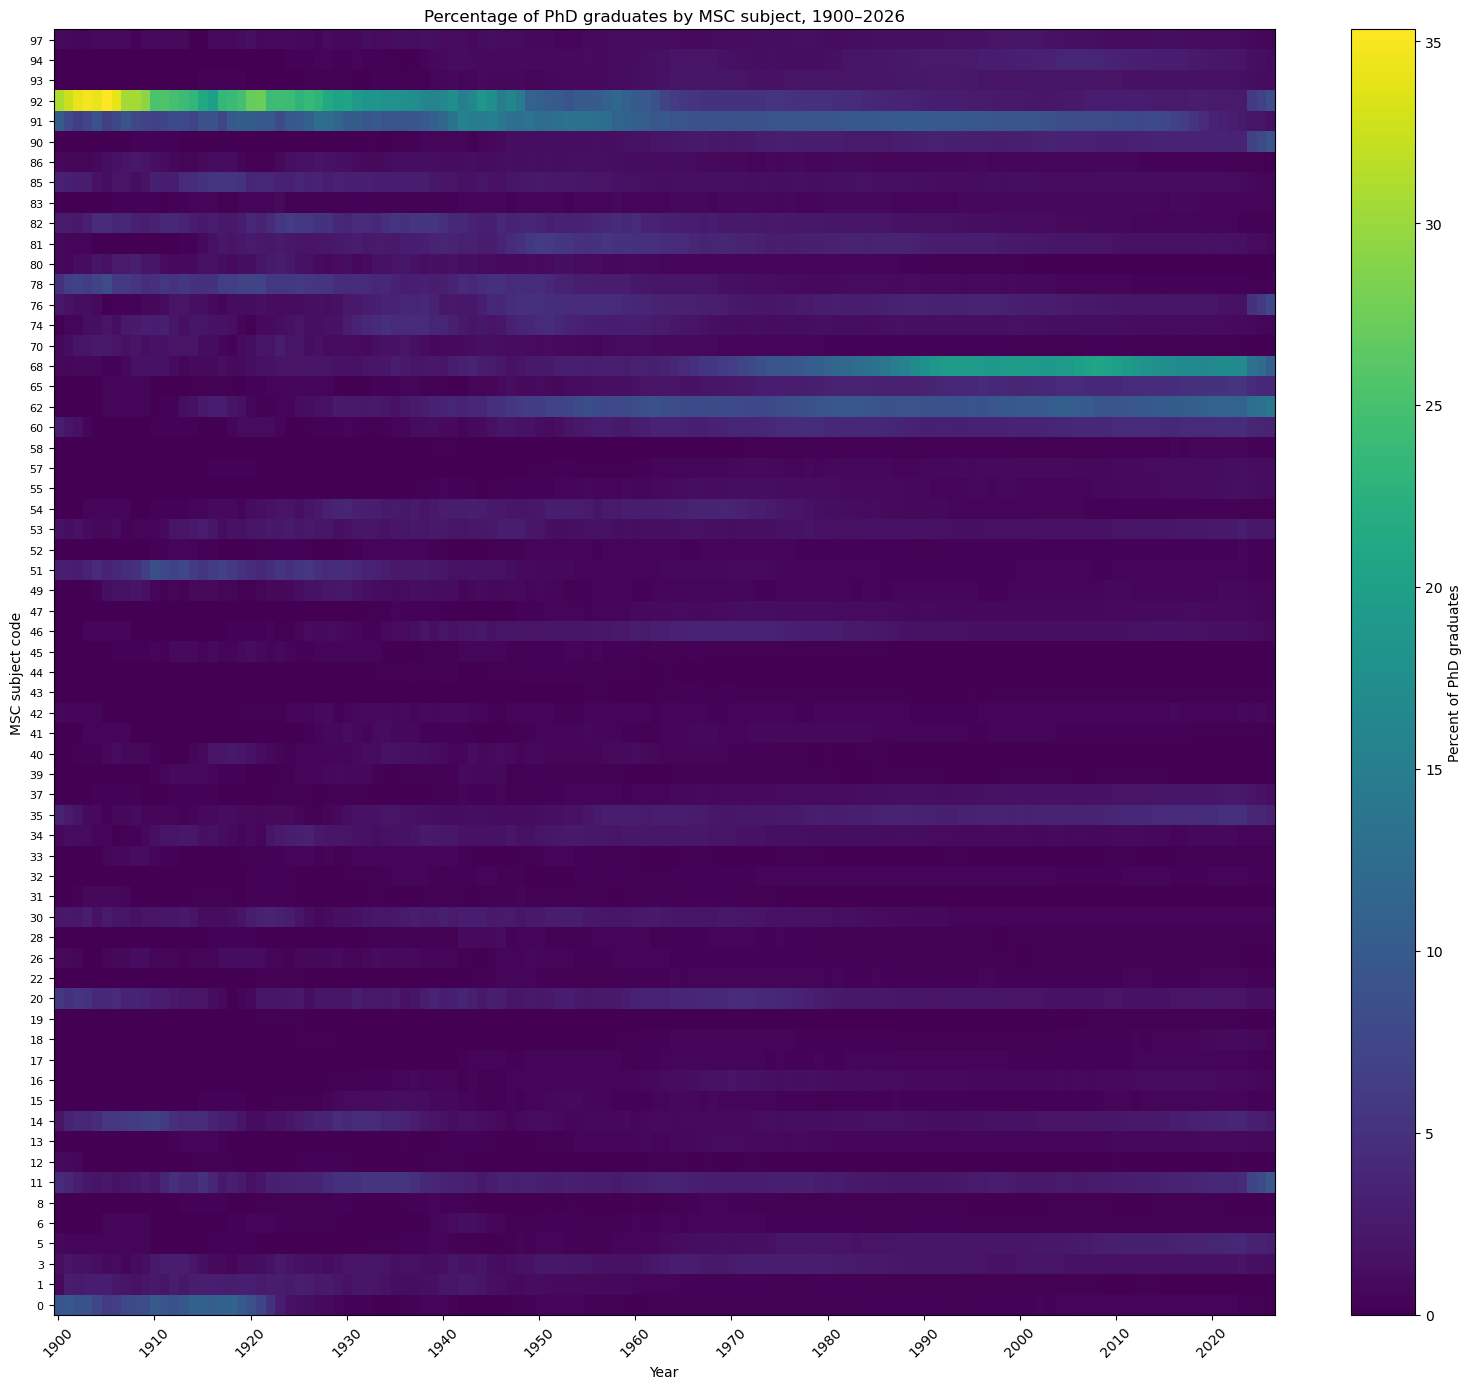

In [116]:
share_smooth = share.T.rolling(5, center=True, min_periods=1).mean().T

fig, ax = plt.subplots(figsize=(16, 14))

im = ax.imshow(
    share_smooth,
    aspect="auto",
    origin="lower",
    interpolation="nearest"
)

ax.set_xticks(np.arange(0, len(years), 10))
ax.set_xticklabels(years[::10], rotation=45)

ax.set_yticks(np.arange(len(codes)))
ax.set_yticklabels([str(int(c)) for c in codes], fontsize=8)

ax.set_xlabel("Year")
ax.set_ylabel("MSC subject code")
ax.set_title("Percentage of PhD graduates by MSC subject, 1900–2026")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Percent of PhD graduates")

plt.tight_layout()
plt.show()

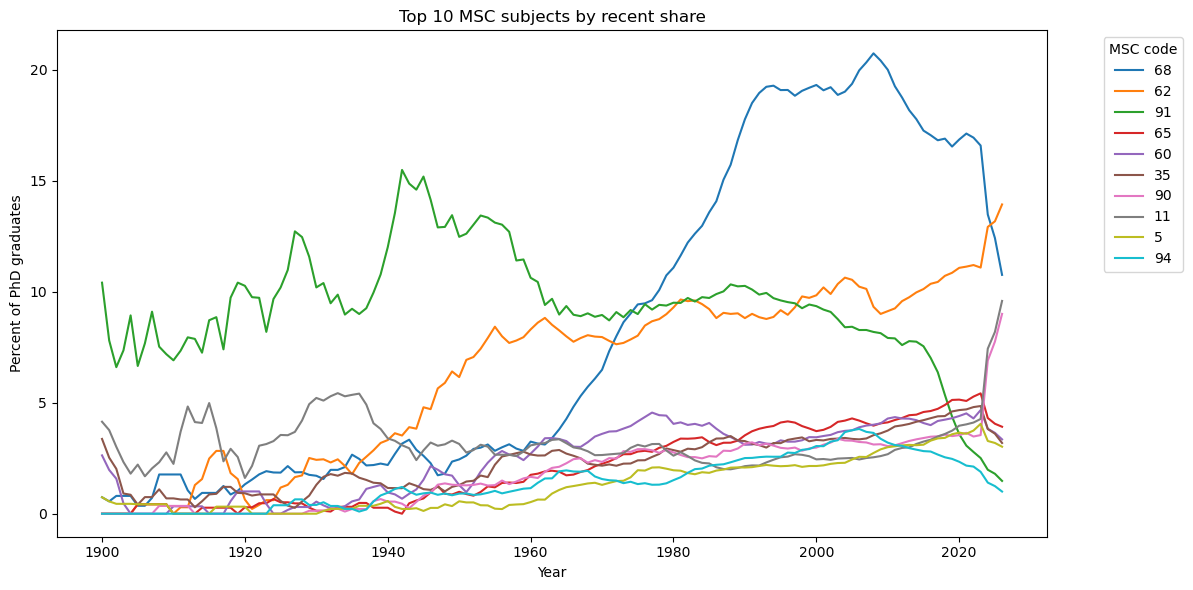

In [117]:
top10 = share.loc[:, 2000:2025].mean(axis=1).sort_values(ascending=False).head(10).index

share_top10 = share.loc[top10].T
share_top10_smooth = share_top10.rolling(5, center=True, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(12, 6))

for code in top10:
    ax.plot(
        share_top10_smooth.index,
        share_top10_smooth[code],
        label=str(int(code))
    )

ax.set_xlabel("Year")
ax.set_ylabel("Percent of PhD graduates")
ax.set_title("Top 10 MSC subjects by recent share")
ax.legend(title="MSC code", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

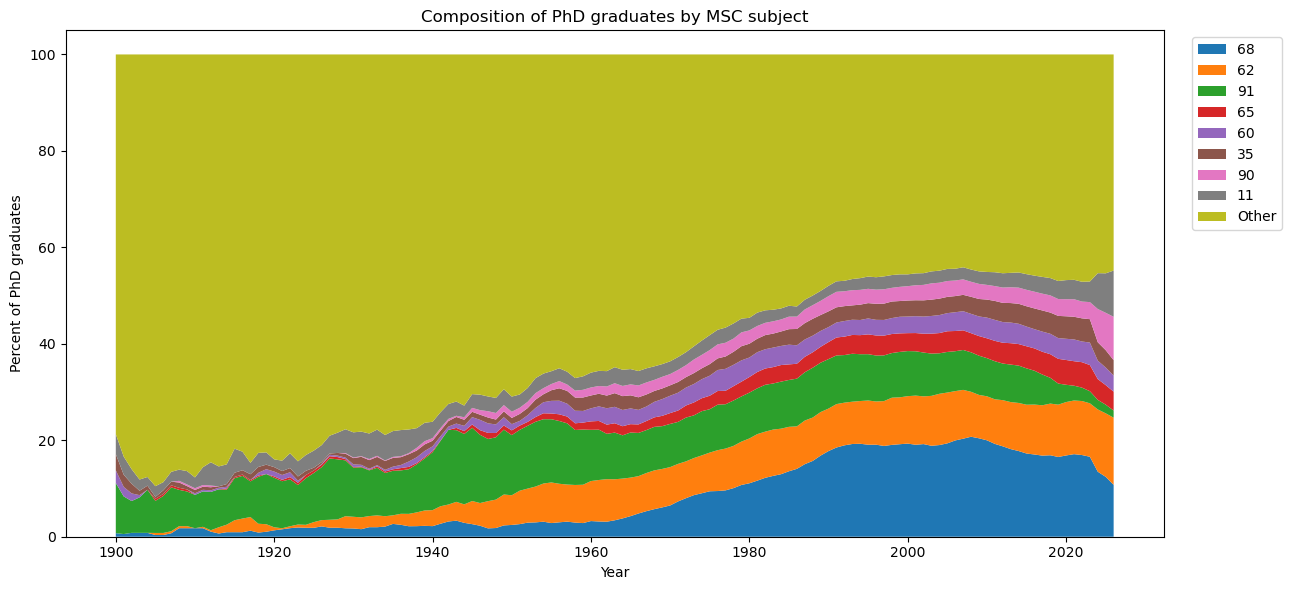

In [118]:
top8 = share.loc[:, 2000:2025].mean(axis=1).sort_values(ascending=False).head(8).index

area_data = share.loc[top8].T.copy()
area_data["Other"] = 100 - area_data.sum(axis=1)

area_data_smooth = area_data.rolling(5, center=True, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(13, 6))

ax.stackplot(
    area_data_smooth.index,
    area_data_smooth.T,
    labels=[str(int(c)) if c != "Other" else "Other" for c in area_data_smooth.columns]
)

ax.set_xlabel("Year")
ax.set_ylabel("Percent of PhD graduates")
ax.set_title("Composition of PhD graduates by MSC subject")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.show()

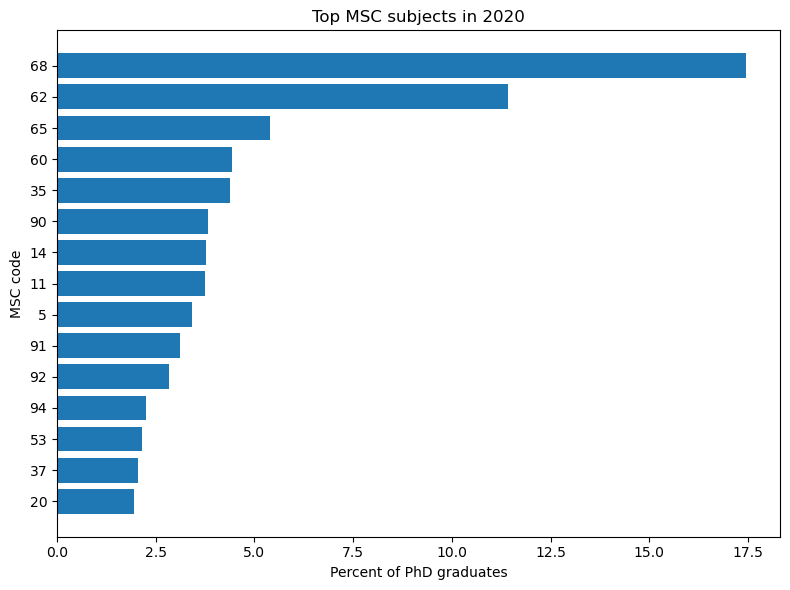

In [119]:
year = 2020

top_year = share[year].sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))

ax.barh([str(int(c)) for c in top_year.index[::-1]], top_year.values[::-1])

ax.set_xlabel("Percent of PhD graduates")
ax.set_ylabel("MSC code")
ax.set_title(f"Top MSC subjects in {year}")

plt.tight_layout()
plt.show()

In [ ]:
#count the subject total (including predicted with confidence>5.5)
C=np.zeros((63,2))
for i in range(63):
    C[i,0]=codes[i]
    C[i,1]=len(nodes[nodes['subject_code']==codes[i]])

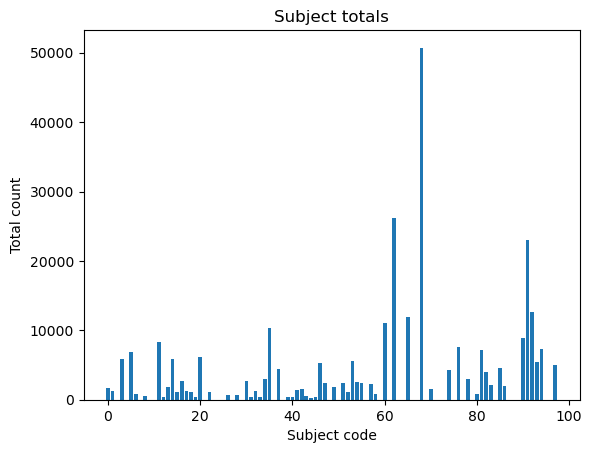

In [132]:
plt.bar(C[:, 0], C[:, 1])
plt.xlabel("Subject code")
plt.ylabel("Total count")
plt.title("Subject totals")
plt.show()

In [134]:
#count the predicted subject total, third column is the ratio
D=np.zeros((63,3))
for i in range(63):
    D[i,0]=codes[i]
    D[i,1]=len(nodes[nodes['predicted_subject_code']==codes[i]])
    D[i,2]=D[i,1]/C[i,1]

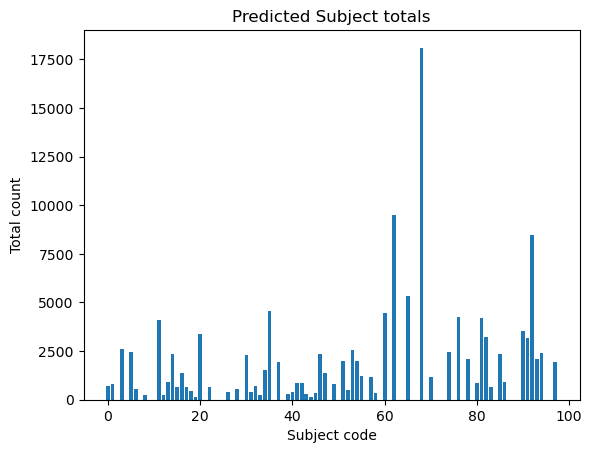

In [136]:
plt.bar(D[:, 0], D[:, 1])
plt.xlabel("Subject code")
plt.ylabel("Total count")
plt.title("Predicted Subject totals")
plt.show()

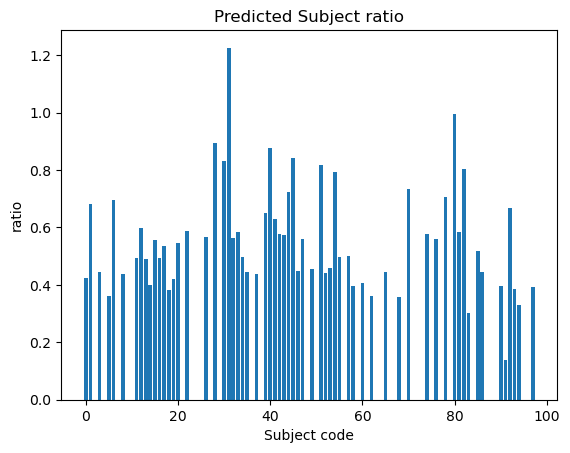

In [138]:
plt.bar(D[:, 0], D[:, 2])
plt.xlabel("Subject code")
plt.ylabel("ratio")
plt.title("Predicted Subject ratio")
plt.show()

In [ ]:
#sanity check
W=[]
for i in range(len(nodes)):
    row = nodes.iloc[i]
    if pd.isna(row["subject_code"]):
        if (not pd.isna(row['predicted_subject_code']))& (row['subject_prediction_confidence']>=0.55):
            W.append(row['id'])
    #if not pd.isna(row["subject_code"]):
    #    if (row['predicted_subject_code']!=row['subject_code']) & (pd.isna(row['subject_prediction_confidence'])):
    #       W.append(row['id'])
print(W)

[np.int64(218952)]


In [163]:
#count the predicted subject with confidence>5.5
E=np.zeros((63,4))
for i in range(63):
    E[i,0]=codes[i]
    E[i,1]=len(nodes[(nodes['subject_code']==codes[i])&(nodes['subject_prediction_confidence']>0.55)])
    E[i,2]=E[i,1]/(C[i,1]-E[i,1])
    E[i,3]=E[i,1]/C[i,1]

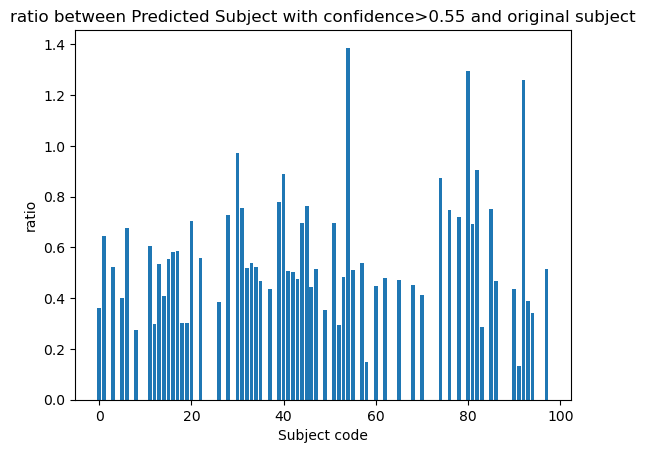

In [162]:
plt.bar(E[:, 0], E[:, 2])
plt.xlabel("Subject code")
plt.ylabel("ratio")
plt.title("ratio between Predicted Subject with confidence>0.55 and original subject")
plt.show()

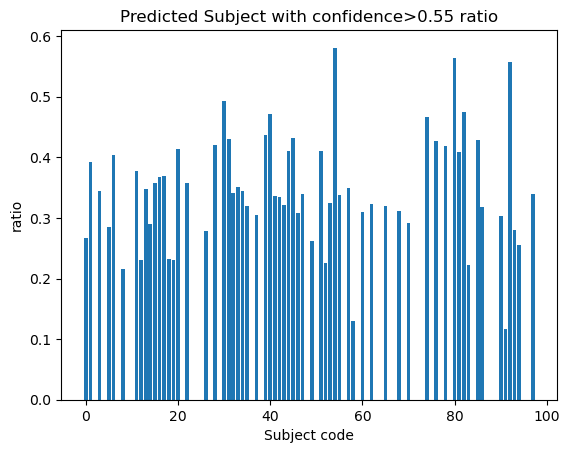

In [166]:
plt.bar(E[:, 0], E[:, 3])
plt.xlabel("Subject code")
plt.ylabel("ratio")
plt.title("Predicted Subject with confidence>0.55 ratio")
plt.show()